# Intelligent Agents: Reflex-Based Agents for GridHunt (Multi-agent Environment)

Student Name: Trương Văn Thiện

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: Thiện

## Learning Outcomes

* Apply core AI concepts by implementing the agent function for a simple and model-based reflex agents that respond to environmental percepts.
* Practice how the environment and the agent function interact.
* Analyze agent performance through controlled experiments across different environment configurations.

## Instructions

Total Points: 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook.
### AI Use

Here are some guidelines that will make it easier for you:

* __Don't:__ Rely on AI auto completion. You will waste a lot of time trying to figure out how the suggested code relates to what we do in class. Turn off AI code completion (e.g., Copilot) in your IDE.
* __Don't:__ Do not submit code/text that you do not understand or have not checked to make sure that it is complete and correct.
* __Do:__ Use AI for debugging and letting it explain code and concepts from class.

## Introduction

![GridHunt Image](gridhunt.png)

Gridhunt is a small educational game that helps you practice implementing simple agent functions. It is a modified Python reimplementation of Gridhunt2. 

The objective of gridhunt is to implement an intelligent agent, the hunter, who can catch a monster faster than all other hunters. Gridhunt uses a $n \times n$ arena consisting of a grid of tiles. Gridhunt is a turn-based game, and several hunter agents and the monster agent move around in the arena. A hunter catches the monster if she/he moves on the same square the monster currently occupies. The hunters compete fow who catches the monster first. If the monster survives the maximum number of steps for the game, then the monster wins.

## PEAS Description of Gridhunt

__Performance Measure:__ The performance is measured as the number of steps the hunter uses to catch the monster. Catching the monster means to be on the same square.

__Environment:__ An arena with $n \times n$ squares. At the beginning the monster and the hunters are randomly placed in the arena environment. The hunters and the monster
    can move around, but cannot leave the arena. Since there are three agents involved, this is a competitive multi-agent environment.

__Actuators:__ The agent can move to an adjacent square using actions "north", "east", "west", and "south", or teleport which will move the agent 
    to a random square in the arena.

__Sensors:__ The agent can always see its location in the arena and the location of the monster.  

## The Arena Environment

The environment manages the location of the agents (hunter and monster). It initially places them in a random location and then provides them in every step with percepts (the location of the hunter and the monster) and asks them for their action. 

__A Note on positions:__
The arena is implemented as an array with row and column indices representing the position.
Positions are stored in a numpy array where `pos[0]` is the row index and `pos[1]` is the column index in the arena. North means up in this array, that is the row index gets smaller when going north. Remember indices in Python start with 0 and go to `n-1`.

In [1]:
import numpy as np
from IPython.display import clear_output
from time import sleep

def arena_environment(hunter_1_agent_function, hunter_2_agent_function, monster_agent_function, n = 30, max_steps = 100, visualize = False, animation = False):
    """
    Simulate an arena where two hunter agent tries to catch a monster agent.

    Parameters:
    hunter_1_agent_function and hunter_2_agent_function (function): A function that takes the current positions of the hunter and monster
                                      and returns the next move for the hunter ('north', 'east', 'west', 'south', 'teleport').
    monster_agent_function (function): A function that takes the current positions of the hunter and monster
                                       and returns the next move for the monster (or 'stay' to remain in place).
    n (int): The size of the arena (n x n grid).
    max_steps (int): The maximum number of steps to simulate.
    visualize (bool): Whether to visualize the arena.
    animation (bool): Whether to animate the visualization with a delay.

    Returns:
    int: The number of steps taken for the hunter to catch the monster or np.nan (not a number) if not caught.
    """
    
    # Initialize positions
    monster_pos = np.random.randint(0, n-1, size=2)
    hunter_1_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_1_pos, monster_pos):
        hunter_1_pos = np.random.randint(0, n-1, size=2)
    hunter_2_pos = np.random.randint(0, n-1, size=2)
    while np.array_equal(hunter_2_pos, monster_pos):
        hunter_2_pos = np.random.randint(0, n-1, size=2)    
    
    def move(action, position):
        """calculate new position for the agent."""
        if action == 'north':
            position[0] -= 1
        elif action == 'south':
            position[0] += 1
        elif action == 'west':
            position[1] -= 1
        elif action == 'east':
            position[1] += 1
        else:
            raise ValueError("Invalid action.")
        
        # Ensure position stays within bounds
        position = np.clip(position, 0, n-1)
        return position

    def print_arena():

        if animation:
            sleep(1)
            clear_output(wait=True)
        print(f"Step {step}:")
        print(f"Hunter 1 is at '{hunter_1_pos}'; Hunter 2 is at '{hunter_2_pos}'; Monster is at '{monster_pos}'\n")
        arena = np.full((n, n), '.', dtype=str)
        arena[monster_pos[0], monster_pos[1]] = 'M'
        arena[hunter_1_pos[0], hunter_1_pos[1]] = '1'
        arena[hunter_2_pos[0], hunter_2_pos[1]] = '2'
        print("\n".join("".join(row) for row in arena))

    for step in range(max_steps):
        if visualize:
            print_arena()
        
        # Check if hunter has caught the monster
        if np.array_equal(hunter_1_pos, monster_pos):
            if visualize:
                print(f"Hunter 1 caught the monster in {step} steps!")
            return ("1", step)
        
        if np.array_equal(hunter_2_pos, monster_pos):
            if visualize:
                print(f"Hunter 2 caught the monster in {step} steps!")
            return ("2", step)

        # Get next move from monster agent function
        monster_action = monster_agent_function(monster_pos, hunter_1_pos, hunter_2_pos)
        if monster_action != 'stay':
            monster_pos = move(monster_action, monster_pos)

        # Get next move from hunter agent function
        hunter_1_action = hunter_1_agent_function(hunter_1_pos, monster_pos)
        if hunter_1_action == 'teleport':
            hunter_1_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_1_pos = move(hunter_1_action, hunter_1_pos)

        hunter_2_action = hunter_2_agent_function(hunter_2_pos, monster_pos)
        if hunter_2_action == 'teleport':
            hunter_2_pos = np.random.randint(0, n-1, size=2)
        else:
            hunter_2_pos = move(hunter_2_action, hunter_2_pos)
    
        # print the agents' actions
        if visualize:
            print(f"Hunter 1 chose action '{hunter_1_action}'")
            print(f"Hunter 2 chose action '{hunter_2_action}'")
            print(f"Monster chose action '{monster_action}'")
            print("\n" + "="*n + "\n")

    # the hunter failed to catch the monster within max_steps
    if visualize:
        print(f"Monster won by surviving {max_steps} steps.")
    
    return ("M", np.nan)

I implement the monster here as a simple agent that moves around randomly, but mostly stays in its place. You can use AI to get a detailed explanation of how the following code works.

In [2]:
monster_actions = ["north", "east", "west", "south", "stay"]

def monster_agent_function_simple(monster_pos, hunter_1_pos, hunter_2_pos):
    return np.random.choice(monster_actions, p=[0.125, 0.125, 0.125, 0.125, 0.5])

# The Hunter Agent

Your job is to implement a simple-reflex hunter agent that can catch the monster. Remember, your agent is implemented as an agent function that get percepts and needs to return a valid action. The actions are: 

In [3]:
actions = ["north", "east", "west", "south", "teleport"]

## A Simple Example Implementation

Here is a very simple hunter that just runs around randomly and hopes that it bumps into the monster. 

In [4]:
def simple_randomized_hunter_agent_function(hunter_location, monster_location):
    return np.random.choice(actions)

Ask the agent for an action.

In [5]:
simple_randomized_hunter_agent_function([0,0], [5,5])

np.str_('north')

## Experimenting With the Agent

We can place the monster and the hunter into the environment and run a simulation by calling the environment function.

In [6]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

arena_environment(hunter_1, 
                  hunter_2, 
                  monster_agent_function_simple, 
                  n=5, max_steps=5, visualize=True, animation=False)

Step 0:
Hunter 1 is at '[0 2]'; Hunter 2 is at '[3 1]'; Monster is at '[0 1]'

.M1..
.....
.....
.2...
.....
Hunter 1 chose action 'teleport'
Hunter 2 chose action 'east'
Monster chose action 'stay'

=====

Step 1:
Hunter 1 is at '[2 3]'; Hunter 2 is at '[3 2]'; Monster is at '[0 1]'

.M...
.....
...1.
..2..
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'east'
Monster chose action 'stay'

=====

Step 2:
Hunter 1 is at '[2 4]'; Hunter 2 is at '[3 3]'; Monster is at '[0 1]'

.M...
.....
....1
...2.
.....
Hunter 1 chose action 'north'
Hunter 2 chose action 'west'
Monster chose action 'stay'

=====

Step 3:
Hunter 1 is at '[1 4]'; Hunter 2 is at '[3 2]'; Monster is at '[0 1]'

.M...
....1
.....
..2..
.....
Hunter 1 chose action 'east'
Hunter 2 chose action 'east'
Monster chose action 'stay'

=====

Step 4:
Hunter 1 is at '[1 4]'; Hunter 2 is at '[3 3]'; Monster is at '[0 1]'

.M...
....1
.....
...2.
.....
Hunter 1 chose action 'teleport'
Hunter 2 chose action 'west'
Monster chos

('M', nan)

Well, this was one run, maybe it was just good or bad luck this time!

Let's run an experiment with 100 runs in a $20 \times 20$ arena.  

In [7]:
hunter_1 = simple_randomized_hunter_agent_function
hunter_2 = simple_randomized_hunter_agent_function

steps = [arena_environment(hunter_1, 
                           hunter_2, 
                           monster_agent_function_simple, 
                           n=20, max_steps=100, visualize=False) for _ in range(100)] 
print(steps)

[('M', nan), ('M', nan), ('1', 23), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('2', 68), ('M', nan), ('1', 9), ('2', 7), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 67), ('M', nan), ('M', nan), ('M', nan), ('2', 95), ('M', nan), ('M', nan), ('2', 39), ('2', 31), ('M', nan), ('M', nan), ('1', 17), ('1', 49), ('M', nan), ('2', 79), ('M', nan), ('M', nan), ('M', nan), ('1', 40), ('2', 20), ('M', nan), ('M', nan), ('M', nan), ('1', 27), ('1', 89), ('M', nan), ('M', nan), ('M', nan), ('2', 11), ('1', 10), ('2', 17), ('2', 96), ('M', nan), ('2', 17), ('1', 94), ('2', 43), ('M', nan), ('2', 97), ('M', nan), ('2', 87), ('2', 51), ('M', nan), ('1', 27), ('M', nan), ('M', nan), ('M', nan), ('M', nan), ('1', 35), ('1', 4), ('M', nan), ('M', nan), ('M', nan), ('1', 5), ('M', nan), ('M', nan), ('2', 75), ('M', nan), ('M', nan), ('M', nan), ('M', nan), (

We just got a list with who one and the number of steps to catch the monster for 100 simulation runs.
Let's analysis the results by counting who won how often.

In [8]:
steps = np.array(steps)

print (f"Hunter 1 won: {np.sum(steps[:,0] == "1")}")
print (f"Hunter 2 won: {np.sum(steps[:,0] == "2")}")
print (f"Monster 1 won: {np.sum(steps[:,0] == "M")}")       


Hunter 1 won: 14
Hunter 2 won: 18
Monster 1 won: 68


The random agent in not a very good hunter. You need to implement a better agent function.

# Your Agent Implementation [4 points]

Write a new hunter agent function that chases the monster. Copy the simple randomized hunter function from above and modify it using rules based on the monster's and the hunter's location. Let your hunter compete with the random agent. You can also come up with several different agents and let them compete against each other.

In [ ]:
def make_smart_hunter():
    """Factory tạo hunter agent mới (tránh state leak giữa các lần chạy)."""
    def hunter_agent_function(hunter_location, monster_location):
        h_row, h_col = hunter_location[0], hunter_location[1]
        m_row, m_col = monster_location[0], monster_location[1]

        row_diff = m_row - h_row
        col_diff = m_col - h_col

        # Di chuyển theo chiều có khoảng cách lớn hơn
        if abs(row_diff) >= abs(col_diff):
                return 'south' if row_diff > 0 else 'north'
        else:
            return 'east' if col_diff > 0 else 'west'

    return hunter_agent_function

## Phân tích chiến lược của Smart Hunter Agent

### Loại tác tử
Smart Hunter là một simple reflex agent (tác tử phản xạ đơn giản). 
Lý do: nó không có trạng thái bên trong mọi quyết định chỉ dựa trên percept hiện tại 
(vị trí của hunter và monster do môi trường cung cấp ở mỗi bước).

### Trạng thái bên trong (internal state)
Không có. Trong môi trường multi-agent này, môi trường luôn cung cấp vị trí monster 
cho hunter ở mỗi bước, nên hunter không cần `listen` hay lưu bộ nhớ. 
Vì vậy hàm `make_smart_hunter()` thực chất chỉ là một wrapper; 
agent có thể được viết trực tiếp thành một hàm thuần (pure function) mà không thay đổi hành vi.

### Chiến lược chọn hành động
Ở mỗi bước, agent tính chênh lệch:
- `row_diff = m_row - h_row`
- `col_diff = m_col - h_col`

Sau đó chọn hành động theo quy tắc greedy Manhattan:
1. Nếu `|row_diff| >= |col_diff|`:
   - `row_diff > 0` → `south`
   - `row_diff < 0` → `north`
2. Ngược lại:
   - `col_diff > 0` → `east`
   - `col_diff < 0` → `west`

### Vì sao chiến lược này hiệu quả?
- Mỗi bước luôn giảm khoảng cách Manhattan đến monster ít nhất 1 đơn vị.
- Monster đứng yên 50% thời gian → hunter nhanh chóng thu hẹp khoảng cách.
- Không dùng `teleport` → không làm mất tiến độ.
- Không cần bộ nhớ → đơn giản, nhanh, không bị state leak giữa các lần chạy.

# Your Experiments [2 points]

Copy the simulation code from above and run experiments with your agent. 
Experiment with larger arenas of at least size $30 \times 30$.

In [10]:
# Smart vs Random — arena 30x30
results = [
    arena_environment(
        make_smart_hunter(),                       # Hunter 1: smart
        simple_randomized_hunter_agent_function,   # Hunter 2: random
        monster_agent_function_simple,
        n=30, max_steps=500, visualize=False
    )
    for _ in range(100)
]

results = np.array(results)
print(f"[n=30] Hunter 1 (smart) won: {np.sum(results[:,0] == '1')}")
print(f"[n=30] Hunter 2 (random) won: {np.sum(results[:,0] == '2')}")
print(f"[n=30] Monster won: {np.sum(results[:,0] == 'M')}")

# Thử với n=50
results_50 = [
    arena_environment(
        make_smart_hunter(),
        simple_randomized_hunter_agent_function,
        monster_agent_function_simple,
        n=50, max_steps=500, visualize=False
    )
    for _ in range(100)
]
results_50 = np.array(results_50)
print(f"\n[n=50] Hunter 1 (smart) won: {np.sum(results_50[:,0] == '1')}")
print(f"[n=50] Hunter 2 (random) won: {np.sum(results_50[:,0] == '2')}")
print(f"[n=50] Monster won: {np.sum(results_50[:,0] == 'M')}")

# Thử với n=100
results_100 = [
    arena_environment(
        make_smart_hunter(),
        simple_randomized_hunter_agent_function,
        monster_agent_function_simple,
        n=100, max_steps=500, visualize=False
    )
    for _ in range(100)
]
results_100 = np.array(results_100)
print(f"\n[n=100] Hunter 1 (smart) won: {np.sum(results_100[:,0] == '1')}")
print(f"[n=100] Hunter 2 (random) won: {np.sum(results_100[:,0] == '2')}")
print(f"[n=100] Monster won: {np.sum(results_100[:,0] == 'M')}")

[n=30] Hunter 1 (smart) won: 100
[n=30] Hunter 2 (random) won: 0
[n=30] Monster won: 0

[n=50] Hunter 1 (smart) won: 99
[n=50] Hunter 2 (random) won: 1
[n=50] Monster won: 0

[n=100] Hunter 1 (smart) won: 98
[n=100] Hunter 2 (random) won: 2
[n=100] Monster won: 0


## Bảng tổng hợp kết quả thí nghiệm (Smart vs Random)

| Kích thước arena | Smart Hunter thắng | Random Hunter thắng | Monster thắng |
|:----------------:|:------------------:|:-------------------:|:-------------:|
| 30 × 30          | 100 / 100          | 0 / 100             | 0 / 100       |
| 50 × 50          | 99 / 100           | 1 / 100             | 0 / 100       |
| 100 × 100        | 98 / 100           | 2 / 100             | 0 / 100       |

### Nhận xét kết quả

Vì sao Smart Hunter thắng gần như tuyệt đối?
Smart Hunter dùng chiến lược greedy Manhattan. Khi monster đứng yên, mỗi bước hunter giảm khoảng cách Manhattan đi 1. Vì monster chủ yếu đứng yên với xác suất 0.5, nên hunter nhanh chóng tiến sát và bắt được monster. Do đó, smart hunter thắng hầu hết các lần.

Vì sao Random Hunter thỉnh thoảng thắng ở n = 50 và n = 100?
Khi arena lớn hơn, khoảng cách ban đầu giữa hunter và monster tăng lên. Smart Hunter cần nhiều bước hơn để bắt monster:

n = 30: trung bình khoảng 26 bước.

n = 50: trung bình khoảng 41 bước.

n = 100: trung bình khoảng 79 bước.

Vì smart hunter mất nhiều bước hơn, random hunter có nhiều cơ hội hơn để tình cờ đi trúng ô của monster. Đó là lý do ở n = 50 và n = 100, random hunter thắng được 1-2 lần. Đây là yếu tố may mắn, không phải vì random hunter thông minh hơn.

Vì sao Monster không thắng lần nào?
Vì max_steps = 500 quá lớn so với số bước cần thiết. Ngay cả ở n = 100, smart hunter chỉ cần trung bình khoảng 79 bước, nhỏ hơn rất nhiều so với 500. Do đó monster gần như không thể sống sót đến hết 500 bước.

## Vẽ biểu đồ so sánh

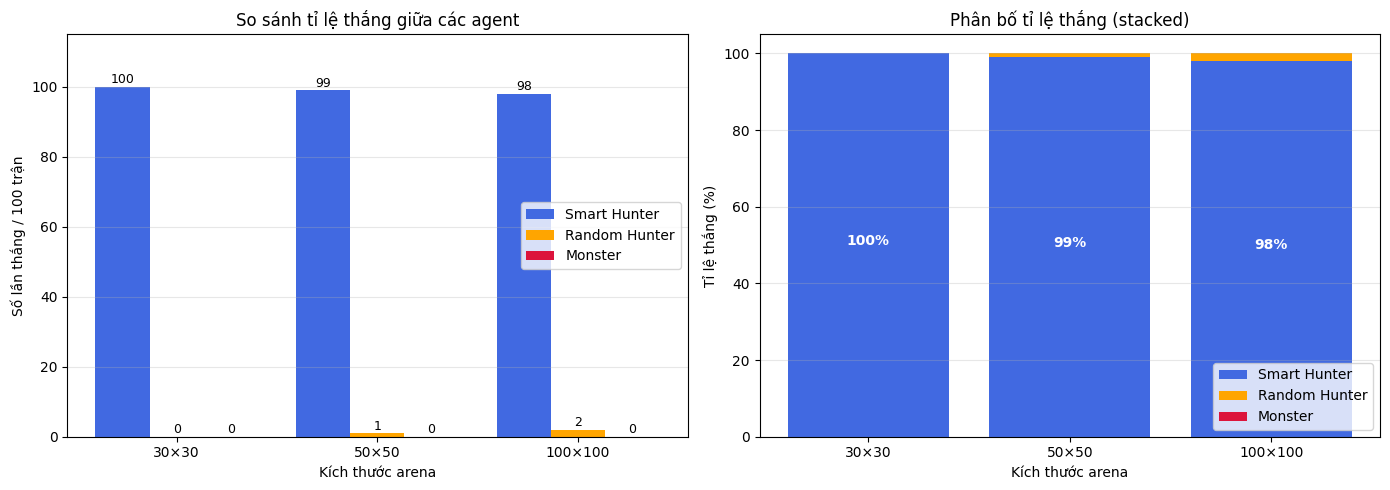

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu từ thí nghiệm
sizes = ['30×30', '50×50', '100×100']
smart_wins  = [100, 99, 98]
random_wins = [0, 1, 2]
monster_wins = [0, 0, 0]

x = np.arange(len(sizes))
width = 0.27

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ 1: Số lần thắng của từng agent ---
bars1 = axes[0].bar(x - width, smart_wins,  width, label='Smart Hunter',  color='royalblue')
bars2 = axes[0].bar(x,          random_wins, width, label='Random Hunter', color='orange')
bars3 = axes[0].bar(x + width,  monster_wins, width, label='Monster',       color='crimson')

for bars in (bars1, bars2, bars3):
    for bar in bars:
        h = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width() / 2, h + 1,
                     f"{int(h)}", ha='center', fontsize=9)

axes[0].set_xticks(x)
axes[0].set_xticklabels(sizes)
axes[0].set_xlabel("Kích thước arena")
axes[0].set_ylabel("Số lần thắng / 100 trận")
axes[0].set_title("So sánh tỉ lệ thắng giữa các agent")
axes[0].legend()
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].set_ylim(0, 115)

# --- Biểu đồ 2: Tỉ lệ thắng dạng phần trăm (stacked) ---
total = np.array(smart_wins) + np.array(random_wins) + np.array(monster_wins)
smart_pct  = 100 * np.array(smart_wins)  / total
random_pct = 100 * np.array(random_wins) / total
monster_pct= 100 * np.array(monster_wins)/ total

axes[1].bar(sizes, smart_pct,  label='Smart Hunter',  color='royalblue')
axes[1].bar(sizes, random_pct, bottom=smart_pct,
            label='Random Hunter', color='orange')
axes[1].bar(sizes, monster_pct,
            bottom=smart_pct + random_pct,
            label='Monster', color='crimson')

for i, s in enumerate(smart_pct):
    axes[1].text(i, s / 2, f"{s:.0f}%", ha='center',
                 color='white', fontweight='bold')

axes[1].set_xlabel("Kích thước arena")
axes[1].set_ylabel("Tỉ lệ thắng (%)")
axes[1].set_title("Phân bố tỉ lệ thắng (stacked)")
axes[1].set_ylim(0, 105)
axes[1].legend(loc='lower right')
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Your Conclusion [4 points] 

Discuss the following:

* What is your hunter's final strategy to choose actions. Why does it work well?
* Do you use teleportation. Why and in what situation? Why not?
* How does the arena size affects your hunter agent's performance?

#### Chiến lược của hunter
Hunter của em là một simple reflex agent. Môi trường luôn cung cấp vị trí của monster, nên hunter không cần bộ nhớ. Ở mỗi bước, hunter tính chênh lệch hàng row_diff và chênh lệch cột col_diff giữa monster và mình. Nếu abs(row_diff) >= abs(col_diff), hunter di chuyển theo hướng bắc hoặc nam để giảm chênh lệch hàng. Ngược lại, hunter di chuyển theo hướng đông hoặc tây để giảm chênh lệch cột. Chiến lược này hoạt động tốt vì nó luôn làm giảm khoảng cách Manhattan đến monster khi monster đứng yên. Vì monster chủ yếu đứng yên với xác suất 0.5, hunter nhanh chóng đuổi kịp.

#### Có dùng teleport không? Vì sao?
Không. Trong môi trường này, hunter luôn biết vị trí monster, nên teleport là hành động ngẫu nhiên và có thể đưa hunter đến ô xa monster hơn, làm mất tiến độ. Teleport chỉ hữu ích khi agent không có thông tin về mục tiêu hoặc bị mắc kẹt. Ở đây, di chuyển trực tiếp về phía monster luôn tốt hơn.

#### Ảnh hưởng của kích thước arena
Khi kích thước arena tăng, khoảng cách ban đầu trung bình giữa hunter và monster cũng tăng theo xấp xỉ 2n/3. Do đó, smart hunter cần nhiều bước hơn để bắt monster. Điều này cũng cho random hunter nhiều cơ hội may mắn hơn, nên tỉ lệ thắng của smart hunter giảm nhẹ từ 100% xuống 99% rồi 98%. Tuy nhiên, monster vẫn không thắng lần nào vì max_steps = 500 quá lớn so với số bước cần thiết.


The monster is also an agent. Describe how the monster's agent function could be changed so it gets better at avoiding the hunter.

#### Monster có thể cải thiện như thế nào?
Monster hiện tại di chuyển ngẫu nhiên và thường đứng yên. Để tránh hunter tốt hơn, monster có thể dùng thông tin về vị trí của cả hai hunter. Ví dụ:

Nếu hunter ở gần, monster chọn bước di chuyển làm tăng khoảng cách đến hunter gần nhất.

Nếu bị dồn vào góc hoặc sát tường, monster chọn hướng vuông góc để thoát ra.

Nếu hunter ở xa, monster có thể đứng yên để tránh vô tình đi vào hunter.

Có thể nâng cao hơn bằng cách dự đoán bước đi tiếp theo của hunter hoặc dùng BFS/minimax để tối đa thời gian sống.

# More Work (optional)

* Improve the monster agent so it tries to run away from the hunters. Don;t make the monster too fast or the hunters will never be able to catch it.
* How could the two hunter agents work together? You need to think about information sharing. This can be implemented by the two agent functions sharing a single Python class or the environment could be expanded by an action "shout" that lets the other agent perceive a message.